Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

print("Libraries imported successfully!")

Libraries imported successfully!


Load the Dataset

In [3]:
df = pd.read_csv("../data/aapl.us.txt")

Display the Dataset

In [4]:
df.head()

,Date,Open,High,Low,Close,Volume,OpenInt
0,1984-09-07,0.42388,0.42902,0.41874,0.42388,23220030,0
1,1984-09-10,0.42388,0.42516,0.41366,0.42134,18022532,0
2,1984-09-11,0.42516,0.43668,0.42516,0.42902,42498199,0
3,1984-09-12,0.42902,0.43157,0.41618,0.41618,37125801,0
4,1984-09-13,0.43927,0.44052,0.43927,0.43927,57822062,0


Check Shape

In [5]:
print("Rows and Columns:", df.shape)

Rows and Columns: (8364, 7)


Check Data Types

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8364 entries, 0 to 8363
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     8364 non-null   str    
 1   Open     8364 non-null   float64
 2   High     8364 non-null   float64
 3   Low      8364 non-null   float64
 4   Close    8364 non-null   float64
 5   Volume   8364 non-null   int64  
 6   OpenInt  8364 non-null   int64  
dtypes: float64(4), int64(2), str(1)
memory usage: 457.5 KB


Missing Values


In [7]:
df.isnull().sum()

Date       0
Open       0
High       0
Low        0
Close      0
Volume     0
OpenInt    0
dtype: int64

Statistical Summary

In [8]:
df["Date"] = pd.to_datetime(df["Date"])

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8364 entries, 0 to 8363
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     8364 non-null   datetime64[us]
 1   Open     8364 non-null   float64       
 2   High     8364 non-null   float64       
 3   Low      8364 non-null   float64       
 4   Close    8364 non-null   float64       
 5   Volume   8364 non-null   int64         
 6   OpenInt  8364 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(2)
memory usage: 457.5 KB


Plot Closing Price

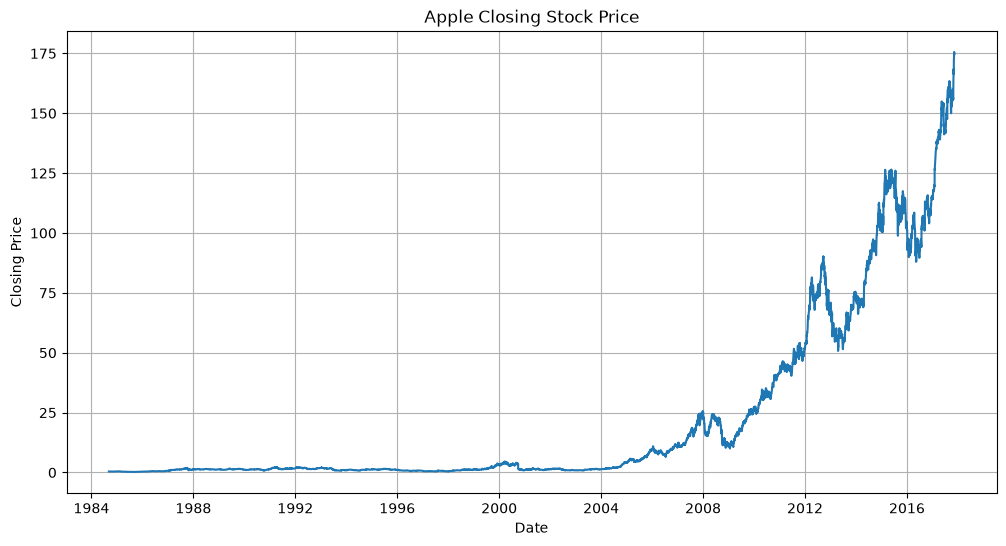

In [10]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Close"])
plt.title("Apple Closing Stock Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)
plt.show()

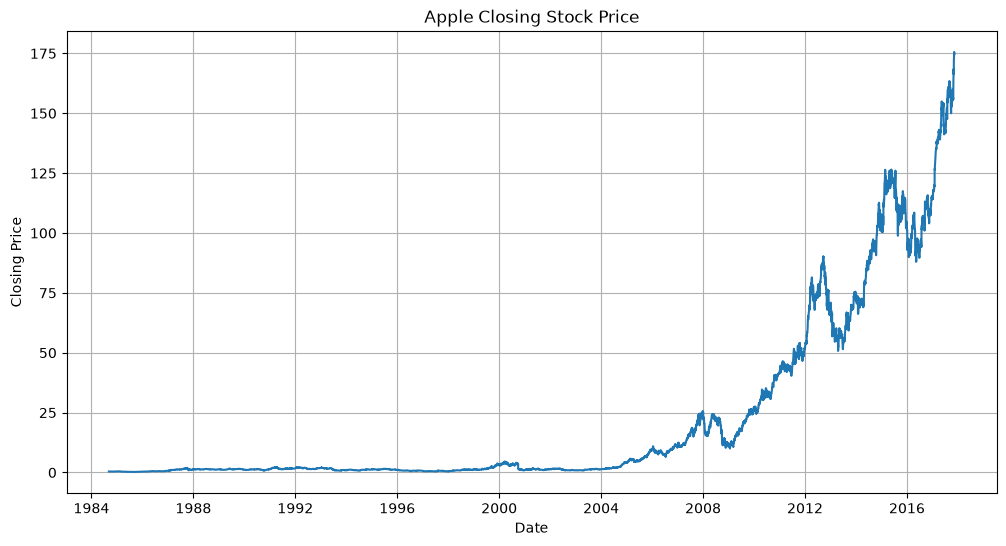

In [11]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Close"])
plt.title("Apple Closing Stock Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)

plt.savefig("../graphs/closing_price.png")

plt.show()

Select the Close Price

In [12]:
close_data = df[['Close']]

close_data.head()

,Close
0,0.42388
1,0.42134
2,0.42902
3,0.41618
4,0.43927


Normalize the Data

In [13]:
scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(close_data)

scaled_data

array([[0.00110258],
       [0.0010881 ],
       [0.00113189],
       ...,
       [1.        ],
       [0.99794731],
       [0.99464019]], shape=(8364, 1))

Check the Shape

In [14]:
print(scaled_data.shape)

(8364, 1)


Create Training Sequences

In [15]:
sequence_length = 60

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])
    y.append(scaled_data[i, 0])

Convert to NumPy Arrays

In [16]:
X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(8304, 60)
(8304,)


Reshape for LSTM

In [17]:
X = X.reshape((X.shape[0], X.shape[1], 1))

print(X.shape)

(8304, 60, 1)


Train-Test Split

In [18]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

Verify Shapes

In [19]:
print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Data : (6643, 60, 1)
Testing Data  : (1661, 60, 1)
Training Labels : (6643,)
Testing Labels  : (1661,)


Build the LSTM Model

In [20]:
model = Sequential()

model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

model.add(LSTM(units=50))
model.add(Dropout(0.2))

model.add(Dense(1))

model.summary()

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

Compile the Model

In [22]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

Train the Model

In [23]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 1.1145e-04 - val_loss: 5.4235e-04
Epoch 2/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.0921e-05 - val_loss: 4.9233e-04
Epoch 3/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.6683e-05 - val_loss: 0.0023
Epoch 4/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 3.2113e-05 - val_loss: 4.6179e-04
Epoch 5/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.4730e-05 - val_loss: 0.0016
Epoch 6/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.3200e-05 - val_loss: 6.3310e-04
Epoch 7/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.0478e-05 - val_loss: 6.9911e-04
Epoch 8/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 3.3700e-05 - val_loss: 8.4395e-04
Epoch 9/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 3.1461e-05 - val_loss: 3.6335e-04
Epoch 10/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 2.6869e-05 - val_loss: 0.0014
Epoch 11/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss:

Plot Training Loss

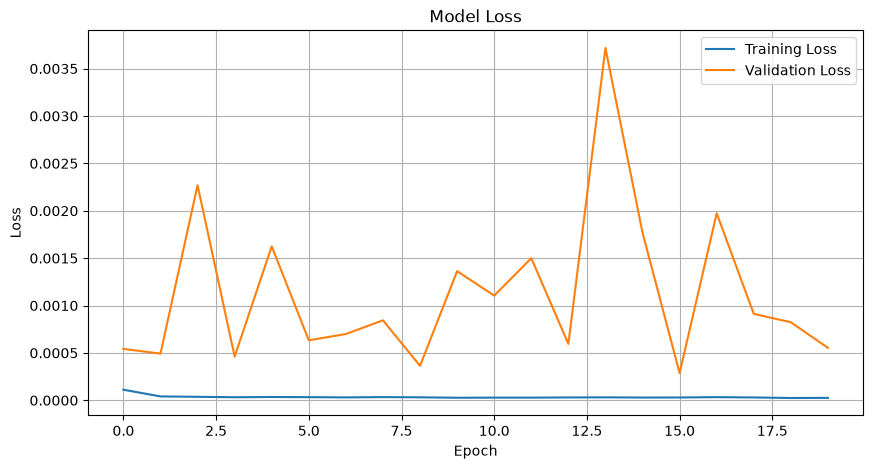

In [24]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.grid(True)

plt.savefig("../graphs/loss.png")

plt.show()